In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/vaish-vkb/Google-Play-Store-Analytics/refs/heads/main/Play%20Store%20Data.csv",quotechar='"', skipinitialspace=True)
df1 = pd.read_csv("https://raw.githubusercontent.com/vaish-vkb/Google-Play-Store-Analytics/refs/heads/main/User%20Reviews.csv",quotechar='"', skipinitialspace=True)


In [3]:
df1.dropna(inplace=True)
df1.head(10)

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
5,10 Best Foods for You,Best way,Positive,1.00,0.300000
6,10 Best Foods for You,Amazing,Positive,0.60,0.900000
8,10 Best Foods for You,"Looking forward app,",Neutral,0.00,0.000000
9,10 Best Foods for You,It helpful site ! It help foods get !,Neutral,0.00,0.000000
10,10 Best Foods for You,good you.,Positive,0.70,0.600000
11,10 Best Foods for You,Useful information The amount spelling errors ...,Positive,0.20,0.100000


In [4]:
df1 = df1.round(2)

In [5]:
specific_val = ['Negative']
only_neg = df1[df1["Sentiment"].isin(specific_val)]
only_neg

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
32,10 Best Foods for You,No recipe book Unable recipe book.,Negative,-0.50,0.50
43,10 Best Foods for You,Waste time It needs internet time n ask calls ...,Negative,-0.20,0.00
68,10 Best Foods for You,Faltu plz waste ur time,Negative,-0.20,0.00
85,10 Best Foods for You,Crap Doesn't work,Negative,-0.80,0.80
95,10 Best Foods for You,Boring. I thought actually just texts that's i...,Negative,-0.32,0.48
...,...,...,...,...,...
64215,Housing-Real Estate & Property,Horrible app. I wanted list property get aroun...,Negative,-0.53,0.72
64216,Housing-Real Estate & Property,Worst app. We get nothing Time waste . They up...,Negative,-0.40,0.25
64220,Housing-Real Estate & Property,"No response support team. After I login, unabl...",Negative,-0.38,0.53
64226,Housing-Real Estate & Property,"Dumb app, I wanted post property rent give opt...",Negative,-0.29,0.25


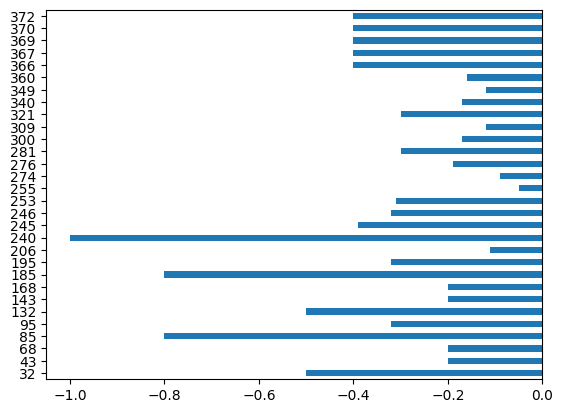

In [6]:
for_Plot= only_neg.head(30)
for_Plot["Sentiment_Polarity"].plot(kind="barh")
plt.show()

In [7]:
df['Installs'] = df['Installs'].astype(str).str.replace(',', '', regex= True).str.replace(r'\+', '', regex=True).str.strip()
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000.0,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000.0,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000.0,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000.0,Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,100000.0,Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,5000.0,Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100.0,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,1000.0,Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,1000.0,Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


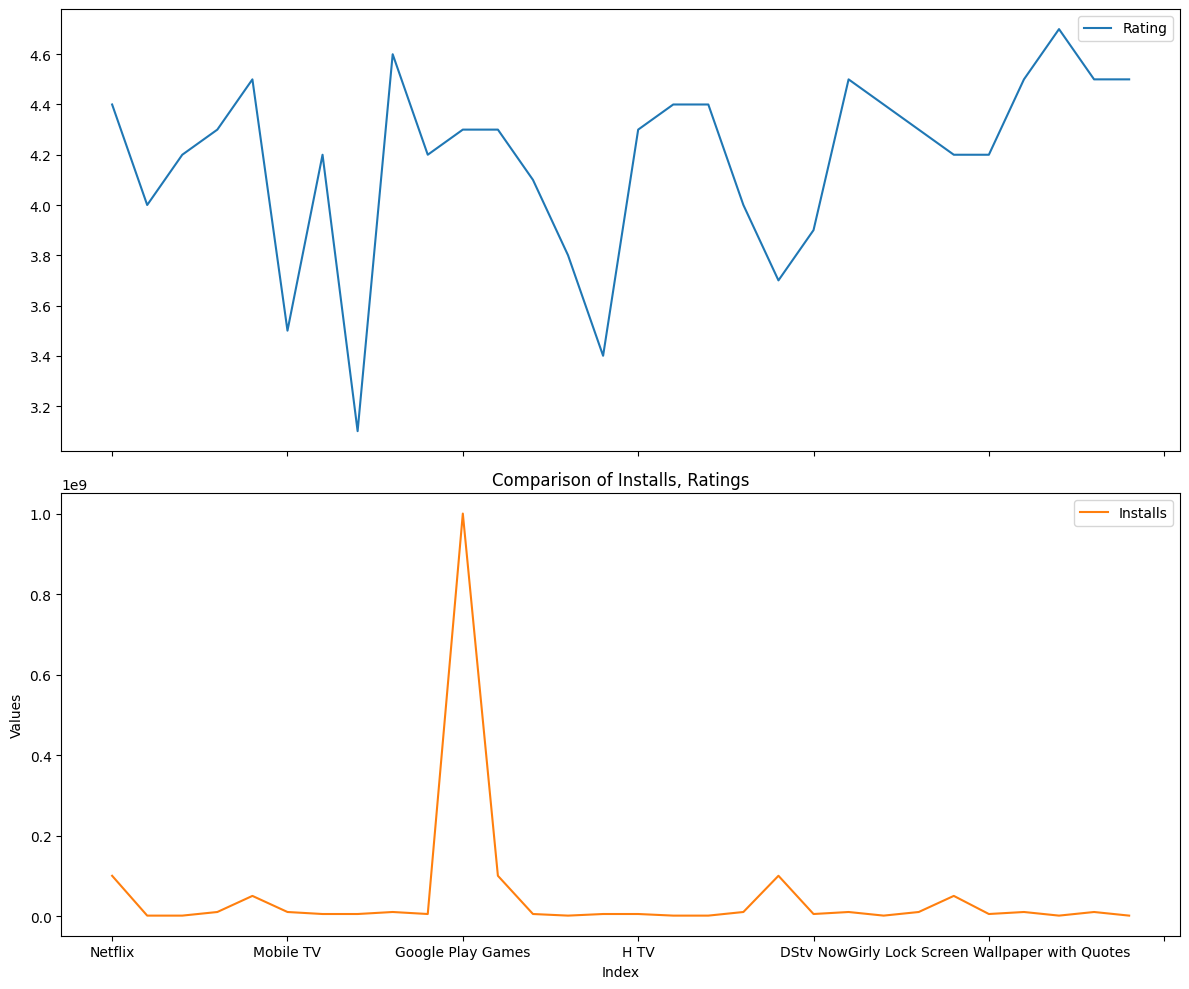

In [8]:
entertainment_df = df[(df['Category'] == 'ENTERTAINMENT') & (df['Installs'] > 500000)]
eplot_df = entertainment_df.set_index('App')[['Rating', 'Installs']].head(30)
eplot_df.plot(subplots=True, figsize=(12,10))
plt.title("Comparison of Installs, Ratings")
plt.xlabel("Index")
plt.ylabel("Values")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
eplot_df

,Rating,Installs
App,,
Netflix,4.4,1.000000e+08
Complete Spanish Movies,4.0,1.000000e+06
Pluto TV - It’s Free TV,4.2,1.000000e+06
Tubi TV - Free Movies & TV,4.3,1.000000e+07
YouTube Kids,4.5,5.000000e+07
Mobile TV,3.5,1.000000e+07
TV+,4.2,5.000000e+06
Digital TV,3.1,5.000000e+06
Motorola Spotlight Player™,4.6,1.000000e+07


In [10]:
df['Category'].unique()

array(['ART_AND_DESIGN', 'AUTO_AND_VEHICLES', 'BEAUTY',
       'BOOKS_AND_REFERENCE', 'BUSINESS', 'COMICS', 'COMMUNICATION',
       'DATING', 'EDUCATION', 'ENTERTAINMENT', 'EVENTS', 'FINANCE',
       'FOOD_AND_DRINK', 'HEALTH_AND_FITNESS', 'HOUSE_AND_HOME',
       'LIBRARIES_AND_DEMO', 'LIFESTYLE', 'GAME', 'FAMILY', 'MEDICAL',
       'SOCIAL', 'SHOPPING', 'PHOTOGRAPHY', 'SPORTS', 'TRAVEL_AND_LOCAL',
       'TOOLS', 'PERSONALIZATION', 'PRODUCTIVITY', 'PARENTING', 'WEATHER',
       'VIDEO_PLAYERS', 'NEWS_AND_MAGAZINES', 'MAPS_AND_NAVIGATION',
       '1.9'], dtype=object)

In [11]:
df1

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.53
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.29
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.88
4,10 Best Foods for You,Best idea us,Positive,1.00,0.30
5,10 Best Foods for You,Best way,Positive,1.00,0.30
...,...,...,...,...,...
64222,Housing-Real Estate & Property,Most ads older many agents ..not much owner po...,Positive,0.17,0.49
64223,Housing-Real Estate & Property,"If photos posted portal load, fit purpose. I'm...",Positive,0.22,0.45
64226,Housing-Real Estate & Property,"Dumb app, I wanted post property rent give opt...",Negative,-0.29,0.25
64227,Housing-Real Estate & Property,I property business got link SMS happy perform...,Positive,0.80,1.00
